In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Use GPU1


In [1]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
print("Available GPUs:", gpus)

#enable memory growth
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)





2025-07-17 22:18:20.099665: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-17 22:18:20.136027: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-17 22:18:20.136052: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-17 22:18:20.136976: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-17 22:18:20.143993: I tensorflow/core/platform/cpu_feature_guar

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import shap
import numpy as np
import tensorflow as tf


In [3]:
tf.keras.backend.clear_session()

import gc
gc.collect()

0

In [4]:
img_size = 40
if img_size == 30 or img_size == 20:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'


# train data

X_train_all_years_Starch_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Starch_shuffled.npy')
X_train_all_years_Brix_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Brix_shuffled.npy')
X_train_all_years_Firmness_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Firmness_shuffled.npy')


X_train_all_years_Starch_encoder   = np.load(f'{training_data_save_path}X_train_all_years_Starch_encoder_shuffled.npy')
X_train_all_years_Firmness_encoder = np.load(f'{training_data_save_path}X_train_all_years_Firmness_encoder_shuffled.npy')
X_train_all_years_Brix_encoder     = np.load(f'{training_data_save_path}X_train_all_years_Brix_encoder_shuffled.npy')

Y_train_Brix       = np.load(f'{training_data_save_path}Y_train_all_years_Brix_shuffled.npy')
Y_train_Starch       = np.load(f'{training_data_save_path}Y_train_all_years_Firmness_shuffled.npy')
Y_train_Firmness       = np.load(f'{training_data_save_path}Y_train_all_years_Starch_shuffled.npy')

In [5]:
img_size = 40
batch_size = 32
num_batches = 5
File_path = '/media/2tbdisk3/data/Haidee/Results/'

In [6]:
spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'
# X_train is the same for all features
# X_train_all_years_Starch_shuffled = [spectral_path + file for file in X_train_all_years_Starch_shuffled] # use brix as the base
X_train_all_years_Brix_shuffled = [spectral_path + file for file in X_train_all_years_Brix_shuffled]
# X_train_all_years_Firmness_shuffled = [spectral_path + file for file in X_train_all_years_Firmness_shuffled]


print(X_train_all_years_Brix_shuffled[:3])

['/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Braeburn_1453_7768.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Fuji_1423_11860.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Gala_125_9429.npy']


In [8]:
# # Test code
# import random
# np.random.seed(771)
# random.seed(771)

# num_samples = 10

# random_indices = random.sample(range(len(X_train_all_years_Brix_shuffled)), num_samples)

# train_sample = [X_train_all_years_Brix_shuffled[i] for i in random_indices]
# cultivar_sample = [X_train_all_years_Brix_encoder[i] for i in random_indices]

# random_indices2 = random.sample(range(len(X_train_all_years_Brix_shuffled)), 100)
# background_sample = [X_train_all_years_Brix_shuffled[i] for i in random_indices2]  
# background_cultivar_sample = [X_train_all_years_Brix_encoder[i] for i in random_indices2]


In [7]:
import random
np.random.seed(771)
random.seed(771)

# Split the indices into cultivars
cultivars = ['Cox', 'Braeburn', 'Fuji', 'Gala', 'Golden Delicious', 'Jazz']
Cultivar_indices = {cultivar: [] for cultivar in cultivars}

for i, path in enumerate(X_train_all_years_Starch_shuffled):
    for cultivar in cultivars:
        if cultivar in path:
            Cultivar_indices[cultivar].append(i)
            

# Get the lengths of each group
group_lengths = {keyword: len(indices) for keyword, indices in Cultivar_indices.items()}
print(group_lengths)

# print(Cultivar_indices)

# Random split of indices into train and test sets by group
background_indices = {cultivar: [] for cultivar in cultivars}
for cultivar, indices in Cultivar_indices.items():
    random.shuffle(indices)
    split_index = int(0.05 * len(indices))  # 5% for background
    background_indices[cultivar] = indices[:split_index] 
    max_indices = int(0.6 *len(indices))
    Cultivar_indices[cultivar] = indices[split_index:max_indices]  # Use only 60% of the total data

# print(background_indices)

background_group_lengths = {keyword: len(indices) for keyword, indices in background_indices.items()}
print(background_group_lengths)

data_group_lengths = {keyword: len(indices) for keyword, indices in Cultivar_indices.items()}
print(data_group_lengths)

# Regroup the indices
X_train = []
X_train_encoder = []
for cultivar, indices in Cultivar_indices.items():
    X_train.extend([X_train_all_years_Brix_shuffled[i] for i in indices])
    X_train_encoder.extend([X_train_all_years_Brix_encoder[i] for i in indices])
X_background_sample = []
X_background_encoder = []
for cultivar, indices in background_indices.items():
    X_background_sample.extend([X_train_all_years_Brix_shuffled[i] for i in indices])
    X_background_encoder.extend([X_train_all_years_Brix_encoder[i] for i in indices])


print(len(X_train))
print(len(X_train_encoder))
print(len(X_background_sample))
print(len(X_background_encoder))

{'Cox': 1127, 'Braeburn': 3718, 'Fuji': 5022, 'Gala': 5489, 'Golden Delicious': 2491, 'Jazz': 60}
{'Cox': 56, 'Braeburn': 185, 'Fuji': 251, 'Gala': 274, 'Golden Delicious': 124, 'Jazz': 3}
{'Cox': 620, 'Braeburn': 2045, 'Fuji': 2762, 'Gala': 3019, 'Golden Delicious': 1370, 'Jazz': 33}
9849
9849
893
893


In [8]:
random.seed(771)
random.shuffle(X_train)
random.shuffle(X_train_encoder)
random.shuffle(X_background_sample)
random.shuffle(X_background_encoder)

In [ ]:
# import pandas as pd

# path = "/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Bayesian_optimisation_files/"

# brix_dict = pd.read_pickle(f'{path}bayesian_optimization_results_brix_ViT.pkl')
# brix_min = brix_dict.loc[brix_dict['val_loss'].idxmin()]
# brix_min['mlp_head_units'] = list(map(int, str(brix_min['mlp_head_units']).split('-')))
# print(brix_min)
# print(brix_min['patch_size'])

# firmness_dict = pd.read_pickle(f'{path}bayesian_optimization_results_firmness_ViT.pkl')
# firmness_min = firmness_dict.copy()
# firmness_min = firmness_min.loc[firmness_dict['val_loss'].idxmin()]
# firmness_min['mlp_head_units'] = list(map(int, str(firmness_min['mlp_head_units']).split('-')))
# print(firmness_min)

# starch_dict = pd.read_pickle(f'{path}bayesian_optimization_results_starch_ViT.pkl')
# starch_min = starch_dict.loc[starch_dict['val_loss'].idxmin()]
# starch_min['mlp_head_units'] = list(map(int, str(starch_min['mlp_head_units']).split('-')))
# print(starch_min)


patch_size                     8
projection_dim               256
transformer_layers             5
num_heads                      3
mlp_head_units        [256, 128]
dropout_rate                 0.1
val_loss                0.725627
Name: 25, dtype: object
8
patch_size                   10
projection_dim               64
transformer_layers            3
num_heads                     5
mlp_head_units        [128, 64]
dropout_rate           0.223294
val_loss               0.549537
Name: 39, dtype: object
patch_size                         9
projection_dim                    66
transformer_layers                 4
num_heads                          4
mlp_head_units        [256, 128, 64]
dropout_rate                0.137285
val_loss                  282.144531
Name: 4, dtype: object


/tmp/ipykernel_897874/4160725113.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brix_min['mlp_head_units'] = list(map(int, str(brix_min['mlp_head_units']).split('-')))
/tmp/ipykernel_897874/4160725113.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  starch_min['mlp_head_units'] = list(map(int, str(starch_min['mlp_head_units']).split('-')))


In [9]:
# Load prediciton models
prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-07-04run_20_40px_model_trained_vit_brix.keras")
prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-07-04run_20_40px_model_trained_vit_firmness.keras")
prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-07-04run_20_40px_model_trained_vit_starch.keras")

2025-07-17 17:06:47.203227: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79086 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:65:00.0, compute capability: 8.0
2025-07-17 17:06:47.205479: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79086 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:ca:00.0, compute capability: 8.0


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPUs will likely run quickly with dtype policy mixed_float16 as they all have compute capability of at least 7.0


In [10]:
def prep_data(file_list, cultivars, img_size):

    # Initialize lists to store the batch data
    batch_data = []
    batch_cultivars = []

    
    # Load the batch of data from file paths
    for i, file in enumerate(file_list):
        try:
            data = np.load(file)
            if img_size == 14:
                data_reduced = data[3:-3, 3:-3, :]
                batch_data.append(data_reduced)
            elif img_size == 40:
                data_reduced = data[5:-5, 5:-5, :]
                batch_data.append(data_reduced)
            else:
                batch_data.append(data)
            batch_cultivars.append(cultivars[i])
        except FileNotFoundError:
            print(f"File not found: {file}. Skipping...")
            continue

    # Convert lists to numpy arrays
    batch_data = np.array(batch_data)  # Shape: (batch_size, img_size, img_size, 204)
    batch_cultivars = np.array(batch_cultivars)  # Shape: (batch_size, 6)

    if len(batch_data) > 0:
        # Expand cultivar information to match the input data's spatial dimensions
        expanded_cultivars = np.repeat(batch_cultivars[:, np.newaxis, np.newaxis, :], img_size, axis=1)
        expanded_cultivars = np.repeat(expanded_cultivars, img_size, axis=2)

        # Concatenate cultivar information with the original data along the last axis
        combined_data = np.concatenate([batch_data, expanded_cultivars], axis=-1)  # Shape: (batch_size, img_size, img_size, 210)

        return combined_data

In [14]:
# prediction_model_brix.summary()

In [11]:
# Test data
# sample_dat = prep_data(X_train, X_train_encoder, img_size, prediction_model_brix)
# background_dat = prep_data(X_background_sample, X_background_encoder, img_size, prediction_model_brix)
sample_dat = prep_data(X_train[:3], X_train_encoder[:3], img_size) # test subset
background_dat = prep_data(X_background_sample, X_background_encoder, img_size)
print(sample_dat.shape)
print(background_dat.shape)

(3, 40, 40, 210)
(893, 40, 40, 210)


In [13]:
print(len(sample_dat))

32


## Process Shap - in .py file

In [12]:
# Wrap the model to only return the regression output
brix_model = tf.keras.Model(
    inputs=prediction_model_brix.input,
    outputs=prediction_model_brix.output["regression"]
)

firmness_model = tf.keras.Model(
    inputs=prediction_model_firmness.input,
    outputs=prediction_model_firmness.output["regression"]
)

starch_model = tf.keras.Model(
    inputs=prediction_model_starch.input,
    outputs=prediction_model_starch.output["regression"]
)

In [22]:
# Create SHAP explainer (e.g., KernelExplainer or GradientExplainer)
# explainer = shap.GradientExplainer(
#     model_predict,
#     data=mean_baseline[np.newaxis, ...]  # Add batch dimension
# )

explainer = shap.GradientExplainer(starch_model, background_dat)

shap_values = explainer.shap_values(sample_dat)

In [18]:
print(len(shap_values))

32


In [36]:
print(shap_values[0].shape)

(40, 40, 210, 1)


In [23]:
print(shap_values[0])

[[[[ 0.01107712]
   [ 0.00887329]
   [ 0.01098287]
   ...
   [-0.01138464]
   [ 0.00333679]
   [ 0.        ]]

  [[ 0.00713932]
   [ 0.0055924 ]
   [ 0.00782063]
   ...
   [-0.01131235]
   [ 0.00340588]
   [ 0.        ]]

  [[ 0.00755448]
   [ 0.00364685]
   [ 0.008752  ]
   ...
   [-0.01137845]
   [ 0.00326626]
   [ 0.        ]]

  ...

  [[ 0.        ]
   [ 0.        ]
   [ 0.        ]
   ...
   [ 0.        ]
   [ 0.        ]
   [ 0.        ]]

  [[ 0.        ]
   [ 0.        ]
   [ 0.        ]
   ...
   [ 0.        ]
   [ 0.        ]
   [ 0.        ]]

  [[ 0.        ]
   [ 0.        ]
   [ 0.        ]
   ...
   [ 0.        ]
   [ 0.        ]
   [ 0.        ]]]


 [[[ 0.01146987]
   [ 0.00816514]
   [ 0.01369345]
   ...
   [-0.01158087]
   [ 0.00331476]
   [ 0.        ]]

  [[ 0.00457879]
   [ 0.00754688]
   [ 0.01284216]
   ...
   [-0.01118628]
   [ 0.00322098]
   [ 0.        ]]

  [[ 0.00823737]
   [ 0.00775164]
   [ 0.0114964 ]
   ...
   [-0.01127047]
   [ 0.00326366]
   [ 0.    

In [38]:
print(sample_dat[0].shape)

(40, 40, 210)


In [ ]:
def run_shap_in_batches(model, background_dat, sample_dat, batch_size=16):
    """
    Computes SHAP values in batches to prevent GPU crashes.
    Returns the concatenated SHAP values across all batches.
    """
    explainer = shap.GradientExplainer(model, background_dat)
    shap_values_all = None

    for i in range(0, len(sample_dat), batch_size):
        batch = sample_dat[i:i + batch_size]
        try:
            shap_vals = explainer.shap_values(batch)

            # Initialize accumulation array if not set
            if shap_values_all is None:
                if isinstance(shap_vals, list):
                    shap_values_all = [np.array(s) for s in shap_vals]
                else:
                    shap_values_all = np.array(shap_vals)
            else:
                if isinstance(shap_vals, list):
                    for j in range(len(shap_vals)):
                        shap_values_all[j] = np.concatenate([shap_values_all[j], shap_vals[j]], axis=0)
                else:
                    shap_values_all = np.concatenate([shap_values_all, shap_vals], axis=0)

        except Exception as e:
            print(f"⚠️ SHAP batch {i}-{i + batch_size} failed: {e}")

    return shap_values_all

# In[ ]:
output_dir = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/May2025/'

# data_types = ['brix', 'firmness', 'starch']
data_types = ['firmness']
for data in data_types:
    print(f"\n=== Running SHAP analysis for {data}")

    model = globals()[f"{data}_model"]

    try:
        # explainer = shap.GradientExplainer(model, background_dat)
        # shap_values = explainer.shap_values(sample_dat)

        shap_values = run_shap_in_batches(model, background_dat, sample_dat, batch_size=16)

        # Save the SHAP values as pkl
        with open(f"{output_dir}shap_values_{data}.pkl", "wb") as f:
            pickle.dump(shap_values, f)
        print(f"SHAP values saved to '{output_dir}shap_values_{data}.pkl'.")

        # Save SHAP values as numpy array
        np.save(f"{output_dir}shap_values_{data}.npy", shap_values)
        print(f"SHAP values saved to '{output_dir}shap_values_{data}.npy'.")
    except Exception as e:
        print(f"❌ SHAP analysis failed for {data}: {e}")

### Load data ###


In [26]:
import shap
import numpy as np
import tensorflow as tf

tf.keras.backend.clear_session()

import gc
gc.collect()
img_size = 40
if img_size == 30 or img_size == 20:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'


# train data

X_train_all_years_Starch_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Starch_shuffled.npy')
X_train_all_years_Brix_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Brix_shuffled.npy')
X_train_all_years_Firmness_shuffled = np.load(f'{training_data_save_path}X_train_all_years_Firmness_shuffled.npy')


X_train_all_years_Starch_encoder   = np.load(f'{training_data_save_path}X_train_all_years_Starch_encoder_shuffled.npy')
X_train_all_years_Firmness_encoder = np.load(f'{training_data_save_path}X_train_all_years_Firmness_encoder_shuffled.npy')
X_train_all_years_Brix_encoder     = np.load(f'{training_data_save_path}X_train_all_years_Brix_encoder_shuffled.npy')

Y_train_Brix       = np.load(f'{training_data_save_path}Y_train_all_years_Brix_shuffled.npy')
Y_train_Starch       = np.load(f'{training_data_save_path}Y_train_all_years_Firmness_shuffled.npy')
Y_train_Firmness       = np.load(f'{training_data_save_path}Y_train_all_years_Starch_shuffled.npy')
img_size = 40
batch_size = 32
num_batches = 5
File_path = '/media/2tbdisk3/data/Haidee/Results/'
spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'
# X_train is the same for all features
# X_train_all_years_Starch_shuffled = [spectral_path + file for file in X_train_all_years_Starch_shuffled] # use brix as the base
X_train_all_years_Brix_shuffled = [spectral_path + file for file in X_train_all_years_Brix_shuffled]
# X_train_all_years_Firmness_shuffled = [spectral_path + file for file in X_train_all_years_Firmness_shuffled]


print(X_train_all_years_Brix_shuffled[:3])

# # Test code
# import random
# np.random.seed(771)
# random.seed(771)

# num_samples = 10

# random_indices = random.sample(range(len(X_train_all_years_Brix_shuffled)), num_samples)

# train_sample = [X_train_all_years_Brix_shuffled[i] for i in random_indices]
# cultivar_sample = [X_train_all_years_Brix_encoder[i] for i in random_indices]

# random_indices2 = random.sample(range(len(X_train_all_years_Brix_shuffled)), 100)
# background_sample = [X_train_all_years_Brix_shuffled[i] for i in random_indices2]  
# background_cultivar_sample = [X_train_all_years_Brix_encoder[i] for i in random_indices2]

import random
np.random.seed(771)
random.seed(771)

# Split the indices into cultivars
cultivars = ['Cox', 'Braeburn', 'Fuji', 'Gala', 'Golden Delicious', 'Jazz']
Cultivar_indices = {cultivar: [] for cultivar in cultivars}

for i, path in enumerate(X_train_all_years_Starch_shuffled):
    for cultivar in cultivars:
        if cultivar in path:
            Cultivar_indices[cultivar].append(i)
            

# Get the lengths of each group
group_lengths = {keyword: len(indices) for keyword, indices in Cultivar_indices.items()}
print(group_lengths)

# print(Cultivar_indices)

# Random split of indices into train and test sets by group
background_indices = {cultivar: [] for cultivar in cultivars}
for cultivar, indices in Cultivar_indices.items():
    random.shuffle(indices)
    split_index = int(0.05 * len(indices))  # 5% for background
    background_indices[cultivar] = indices[:split_index] 
    max_indices = int(0.6 *len(indices))
    Cultivar_indices[cultivar] = indices[split_index:max_indices]  # Use only 60% of the total data

# print(background_indices)

background_group_lengths = {keyword: len(indices) for keyword, indices in background_indices.items()}
print(background_group_lengths)

data_group_lengths = {keyword: len(indices) for keyword, indices in Cultivar_indices.items()}
print(data_group_lengths)

# Regroup the indices
X_train = []
X_train_encoder = []
for cultivar, indices in Cultivar_indices.items():
    X_train.extend([X_train_all_years_Brix_shuffled[i] for i in indices])
    X_train_encoder.extend([X_train_all_years_Brix_encoder[i] for i in indices])
X_background_sample = []
X_background_encoder = []
for cultivar, indices in background_indices.items():
    X_background_sample.extend([X_train_all_years_Brix_shuffled[i] for i in indices])
    X_background_encoder.extend([X_train_all_years_Brix_encoder[i] for i in indices])


print(len(X_train))
print(len(X_train_encoder))
print(len(X_background_sample))
print(len(X_background_encoder))
random.seed(771)
random.shuffle(X_train)
random.shuffle(X_train_encoder)
random.shuffle(X_background_sample)
random.shuffle(X_background_encoder)

2025-07-13 15:23:01.659636: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-13 15:23:01.696586: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-13 15:23:01.696609: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-13 15:23:01.697568: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-13 15:23:01.704590: I tensorflow/core/platform/cpu_feature_guar

['/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Braeburn_1453_7768.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Fuji_1423_11860.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Gala_125_9429.npy']
{'Cox': 1127, 'Braeburn': 3718, 'Fuji': 5022, 'Gala': 5489, 'Golden Delicious': 2491, 'Jazz': 60}
{'Cox': 56, 'Braeburn': 185, 'Fuji': 251, 'Gala': 274, 'Golden Delicious': 124, 'Jazz': 3}
{'Cox': 620, 'Braeburn': 2045, 'Fuji': 2762, 'Gala': 3019, 'Golden Delicious': 1370, 'Jazz': 33}
9849
9849
893
893


## Analysis

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load data
output_dir = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/May2025/'

brix_shap = pd.read_pickle(f'{output_dir}shap_values_brix.pkl')
firmness_shap = pd.read_pickle(f'{output_dir}shap_values_firmness.pkl')
starch_shap = pd.read_pickle(f'{output_dir}shap_values_starch.pkl')

In [ ]:
sample_dat = prep_data(X_train[:3], X_train_encoder[:3], img_size) # test subset
background_dat = prep_data(X_background_sample, X_background_encoder, img_size)
print(sample_dat.shape)
print(background_dat.shape)

KeyboardInterrupt: 

(40, 40, 210)


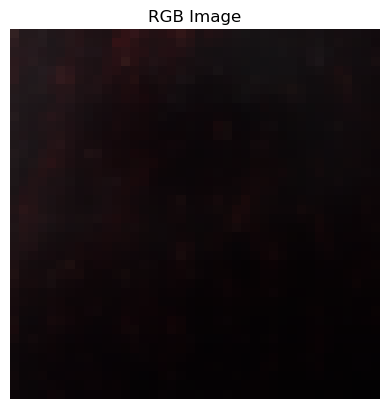

(40, 40, 1)


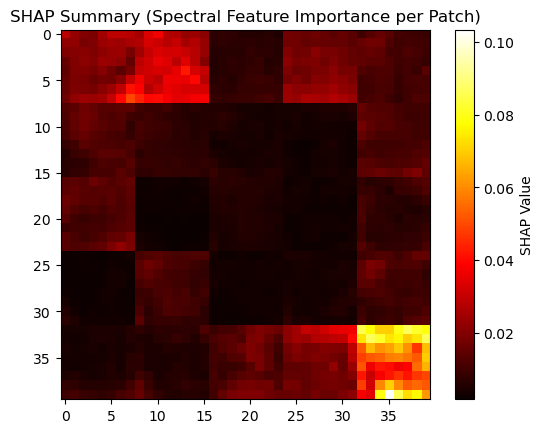

In [15]:
# Looking at the importance of each pixel - one image at a time

num = 0
# if sample_num % 1000 == 0:
original_RGB_img = sample_dat[num]
print(original_RGB_img.shape)
red_band = original_RGB_img[:, :, 69]
green_band = original_RGB_img[:, :, 52]
blue_band = original_RGB_img[:, :, 18]
rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# # Display image
plt.imshow(rgb_image)
plt.axis("off")
plt.title("RGB Image")
plt.show()
# # for a single sample
shap_img = brix_shap[num, :, :, :204] # Exclude the cultivar information for now
# print(type(shap_img))
input_img = sample_dat[[num], :, :, :204]  

# Summarise across spectral bands
shap_summary = np.sum(np.abs(shap_img), axis=2)  # Shape: (img_size, img_size)
print(shap_summary.shape)
# print(shap_summary)
plt.imshow(shap_summary, cmap='hot')
plt.title("SHAP Summary (Spectral Feature Importance per Patch)")
plt.colorbar(label="SHAP Value")
plt.show()



### Start from here ##

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data
output_dir = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/May2025/'

brix_shap = pd.read_pickle(f'{output_dir}shap_values_brix.pkl')
firmness_shap = pd.read_pickle(f'{output_dir}shap_values_firmness.pkl')
starch_shap = pd.read_pickle(f'{output_dir}shap_values_starch.pkl')

In [3]:
# wavebands from Specim IQ camera

wavebands = ['397.32', '400.20', '403.09', '405.97', '408.85', '411.74', '414.63', '417.52', '420.40', '423.29', '426.19', '429.08', '431.97', '434.87', '437.76', '440.66', '443.56', '446.45', '449.35', '452.25', '455.16', '458.06', '460.96', '463.87', '466.77', '469.68', '472.59', '475.50', '478.41', '481.32', '484.23', '487.14', '490.06', '492.97', '495.89', '498.80', '501.72', '504.64', '507.56', '510.48', '513.40', '516.33', '519.25', '522.18', '525.10', '528.03', '530.96', '533.89', '536.82', '539.75', '542.68', '545.62', '548.55', '551.49', '554.43', '557.36', '560.30', '563.24', '566.18', '569.12', '572.07', '575.01', '577.96', '580.90', '583.85', '586.80', '589.75', '592.70', '595.65', '598.60', '601.55', '604.51', '607.46', '610.42', '613.38', '616.34', '619.30', '622.26', '625.22', '628.18', '631.15', '634.11', '637.08', '640.04', '643.01', '645.98', '648.95', '651.92', '654.89', '657.87', '660.84', '663.81', '666.79', '669.77', '672.75', '675.73', '678.71', '681.69', '684.67', '687.65', '690.64', '693.62', '696.61', '699.60', '702.58', '705.57', '708.57', '711.56', '714.55', '717.54', '720.54', '723.53', '726.53', '729.53', '732.53', '735.53', '738.53', '741.53', '744.53', '747.54', '750.54', '753.55', '756.56', '759.56', '762.57', '765.58', '768.60', '771.61', '774.62', '777.64', '780.65', '783.67', '786.68', '789.70', '792.72', '795.74', '798.77', '801.79', '804.81', '807.84', '810.86', '813.89', '816.92', '819.95', '822.98', '826.01', '829.04', '832.07', '835.11', '838.14', '841.18', '844.22', '847.25', '850.29', '853.33', '856.37', '859.42', '862.46', '865.50', '868.55', '871.60', '874.64', '877.69', '880.74', '883.79', '886.84', '889.90', '892.95', '896.01', '899.06', '902.12', '905.18', '908.24', '911.30', '914.36', '917.42', '920.48', '923.55', '926.61', '929.68', '932.74', '935.81', '938.88', '941.95', '945.02', '948.10', '951.17', '954.24', '957.32', '960.40', '963.47', '966.55', '969.63', '972.71', '975.79', '978.88', '981.96', '985.05', '988.13', '991.22', '994.31', '997.40', '1000.49', '1003.58']


def convert_to_numeric(string_list):
    return [float(item) for item in string_list]

wavebands_numeric = convert_to_numeric(wavebands)



In [4]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_shap_values(ax1, ax2, shap_values, wavebands_numeric, main_label, sublabel1, sublabel2, data_type, percentage_to_discard = 80):
    """
    Plot SHAP values across wavelengths and filtered values.

    Parameters:
    ax1 (matplotlib.axes._subplots.AxesSubplot): Axis for the first plot.
    ax2 (matplotlib.axes._subplots.AxesSubplot): Axis for the second plot.
    shap_values (np.array): SHAP values array with shape (num_samples, img_size, img_size, num_bands).
    wavebands_numeric (np.array): Array of wavebands.
    main_label (str): Main label for the plot (e.g., '1', '2', '3').
    sublabel1 (str): Sublabel for the first subplot (e.g., 'A').
    sublabel2 (str): Sublabel for the second subplot (e.g., 'B').
    """
    # Flatten spatial dims and average over pixels and samples
    mean_shap_per_band = np.mean(np.abs(shap_values[:,:,:,:204]), axis=(0, 1, 2)) # Shape: (num_bands,)
    print(mean_shap_per_band.shape)

    # Plot of all values across wavelengths
    ax1.plot(wavebands_numeric, mean_shap_per_band)
    ax1.set_title(f"{data_type}")
    ax1.set_xlabel("Wavelength Index")
    ax1.set_ylabel("Mean SHAP Value")
    ax1.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax1.grid(True)
    ax1.text(-0.1, 1.05, f"{main_label}{sublabel1}", transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))

    # Create a summary plot to show the importance of each spectrum in decreasing order
    mean_shap_per_band_flattened = mean_shap_per_band.flatten()
    threshold = np.percentile(mean_shap_per_band_flattened, percentage_to_discard) # keep top 20% of the values
    selected_features_threshold = mean_shap_per_band_flattened > threshold
    filtered_spectra_data = mean_shap_per_band_flattened[selected_features_threshold]
    filtered_wavebands = np.array(wavebands_numeric)[selected_features_threshold]

    sorted_indices = np.argsort(filtered_spectra_data)[::1] # Sort in ascending order
    sorted_filtered_spectra_data = filtered_spectra_data[sorted_indices]
    sorted_filtered_wavebands = np.array(filtered_wavebands)[sorted_indices]

    # Create a bar plot for the sorted mean SHAP values
    ax2.barh(range(len(sorted_filtered_spectra_data)), sorted_filtered_spectra_data)
    ax2.set_yticks(range(len(sorted_filtered_spectra_data)), sorted_filtered_wavebands, rotation='horizontal')
    ax2.set_ylabel("Wavebands")
    ax2.set_yticklabels([f"{wb:.2f}" for wb in sorted_filtered_wavebands], rotation='horizontal')
    ax2.set_xlabel("Mean SHAP Value")
    ax2.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax2.grid(True)
    ax2.text(-0.1, 1.05, f"{main_label}{sublabel2}", transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))



(204, 1)
(204, 1)
(204, 1)


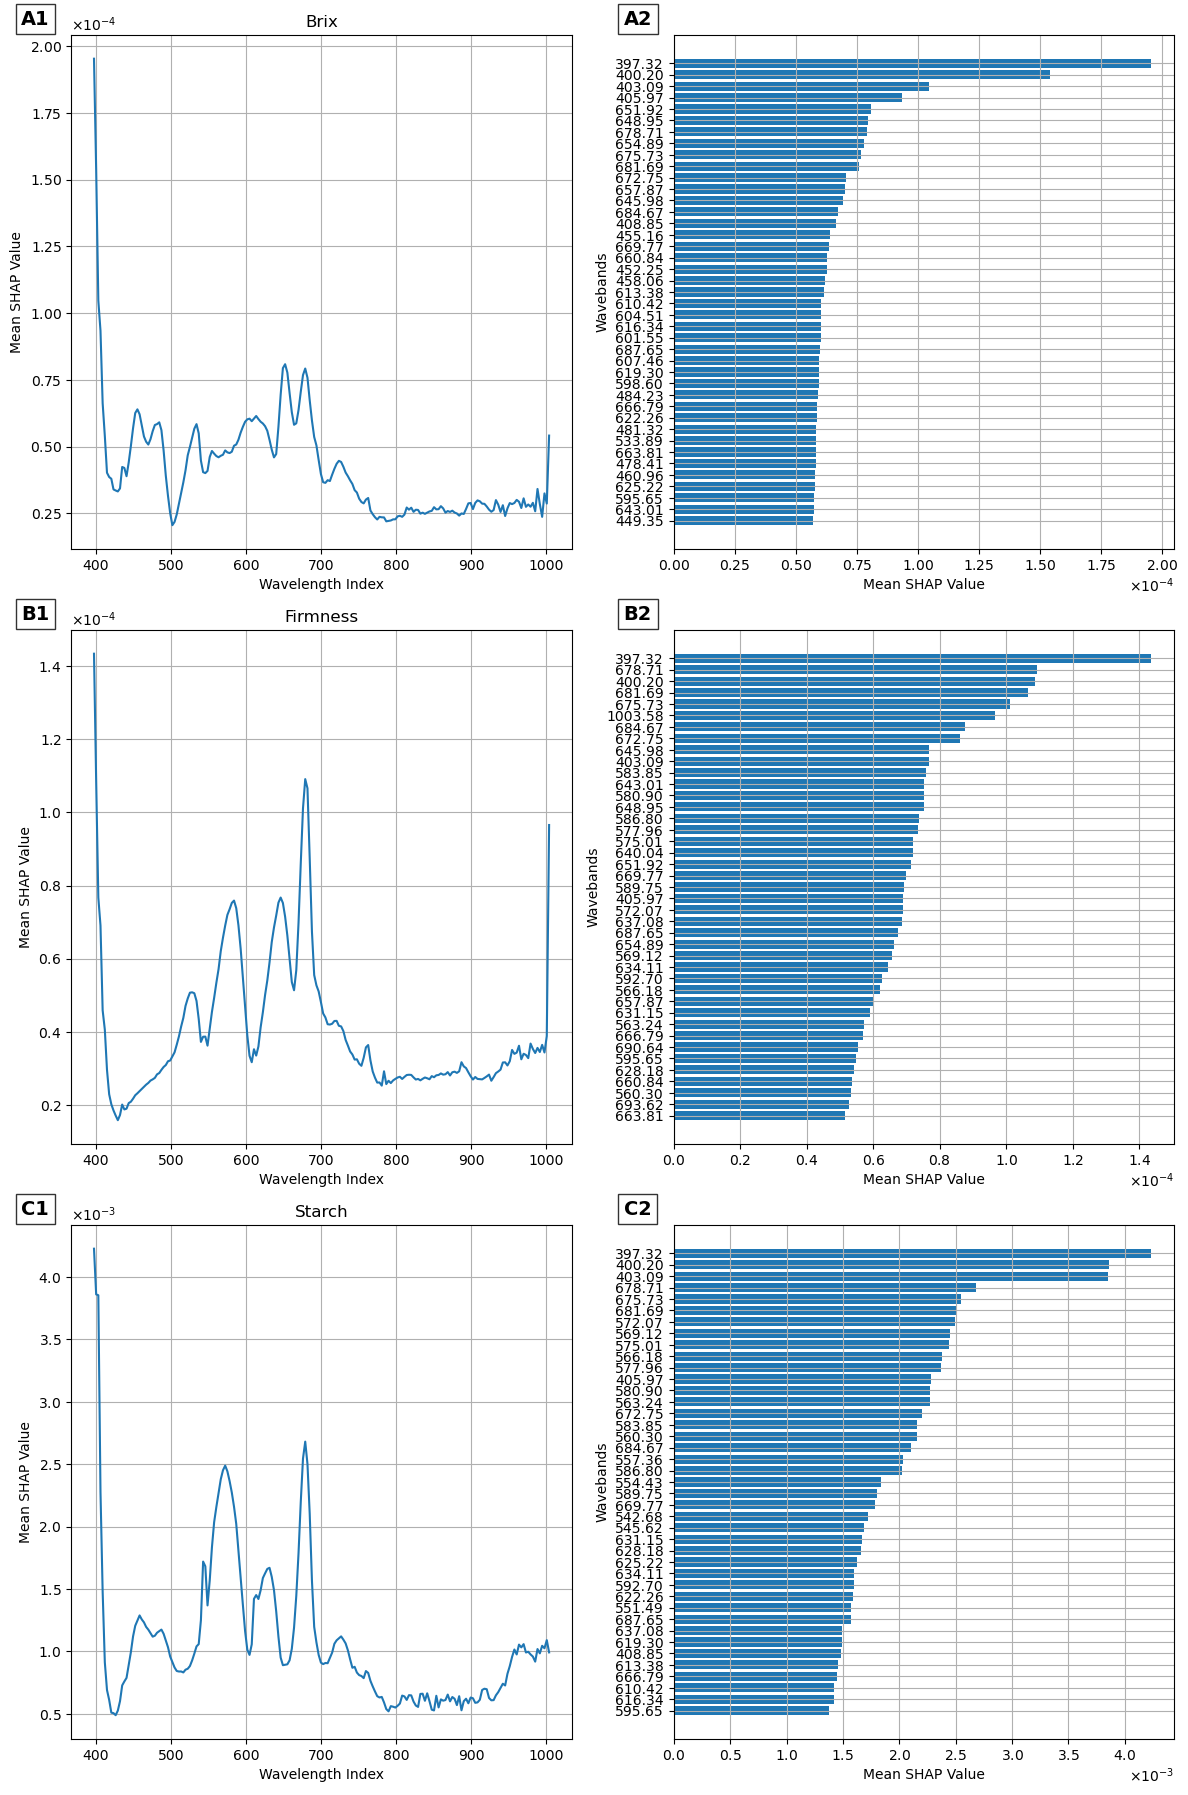

In [5]:
# Plot SHAP values for Brix, Starch, and Firmness in a single figure
fig, axes = plt.subplots(3, 2, figsize=(12, 18))

# Brix
plot_shap_values(axes[0, 0], axes[0, 1], brix_shap, wavebands_numeric, "A", "1", "2", "Brix")

# Firmness
plot_shap_values(axes[1, 0], axes[1, 1], firmness_shap, wavebands_numeric, "B", "1", "2", "Firmness")

# Starch
plot_shap_values(axes[2, 0], axes[2, 1], starch_shap, wavebands_numeric, "C", "1", "2", "Starch")

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_shap_values_side_by_side(ax, shap_values, wavebands_numeric, main_label, data_type, percentage_to_discard=80, order = 'descending'):
    """
    Plot SHAP values across wavelengths and filtered values in a horizontal bar chart.

    Parameters:
        ax (matplotlib.axes.Axes): The axis to plot on.
        shap_values (np.array): SHAP values array with shape (num_samples, img_size, img_size, num_bands).
        wavebands_numeric (np.array): Array of wavebands.
        main_label (str): Main label for the plot (e.g., 'A', 'B', 'C').
        sublabel (str): Sublabel for the subplot (e.g., '1').
        data_type (str): Label for the data type (e.g., 'Brix').
        percentage_to_discard (int): Percentage of low-importance features to discard.
    """
    # Flatten spatial dims and average over pixels and samples
    mean_shap_per_band = np.mean(np.abs(shap_values[:,:,:,:204]), axis=(0, 1, 2)) # Shape: (num_bands,)
    mean_shap_per_band_flattened = mean_shap_per_band.flatten()
    threshold = np.percentile(mean_shap_per_band_flattened, percentage_to_discard) # keep top 20% of the values
    selected_features_threshold = mean_shap_per_band_flattened > threshold
    filtered_spectra_data = mean_shap_per_band_flattened[selected_features_threshold]
    print(len(mean_shap_per_band_flattened))
    print(len(selected_features_threshold))
    filtered_wavebands = np.array(wavebands_numeric)[selected_features_threshold]

    if order == 'descending':
        sorted_indices = np.argsort(filtered_spectra_data)[::1] # Sort in ascending order
        sorted_filtered_spectra_data = filtered_spectra_data[sorted_indices]
        sorted_filtered_wavebands = np.array(filtered_wavebands)[sorted_indices]
    else:
        sorted_filtered_spectra_data = filtered_spectra_data
        sorted_filtered_wavebands = filtered_wavebands

    ax.barh(range(len(sorted_filtered_spectra_data)), sorted_filtered_spectra_data)
    ax.set_title(f"{data_type}")
    ax.set_yticks(range(len(sorted_filtered_spectra_data)), sorted_filtered_wavebands, rotation='horizontal')
    ax.set_ylabel("Wavebands")
    ax.set_yticklabels([f"{wb:.2f}" for wb in sorted_filtered_wavebands], rotation='horizontal')
    ax.set_xlabel("Mean SHAP Value")
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax.grid(True)
    ax.text(-0.1, 1.05, f"{main_label}", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))





204
204
204
204
204
204


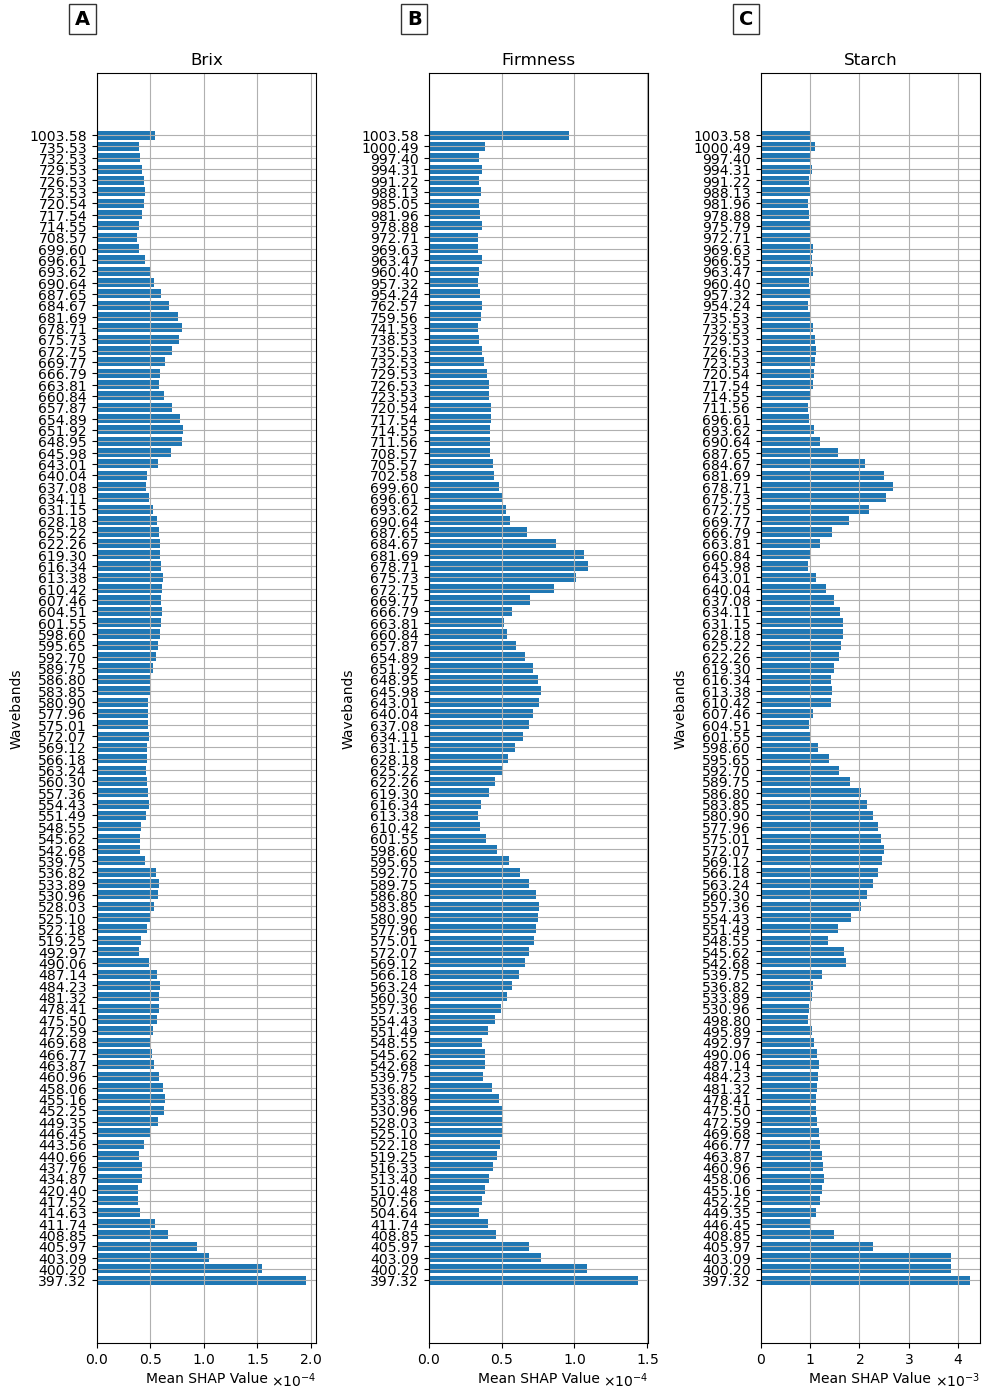

In [7]:
# Plot SHAP values for Brix, Starch, and Firmness in a single figure
fig, axes = plt.subplots(1, 3, figsize=(10, 14))

plot_shap_values_side_by_side(axes[0], brix_shap, wavebands_numeric, "A", "Brix", percentage_to_discard=50, order = 'na')
plot_shap_values_side_by_side(axes[1], firmness_shap, wavebands_numeric, "B", "Firmness", percentage_to_discard=50, order = 'na')
plot_shap_values_side_by_side(axes[2], starch_shap, wavebands_numeric, "C", "Starch", percentage_to_discard=50, order = 'na')

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_shap_values_side_by_side(ax, shap_values, wavebands_numeric, main_label, data_type, percentage_to_discard=80):
    """
    Plot SHAP values across wavelengths and filtered values in a horizontal bar chart.

    Parameters:
        ax (matplotlib.axes.Axes): The axis to plot on.
        shap_values (np.array): SHAP values array with shape (num_samples, img_size, img_size, num_bands).
        wavebands_numeric (np.array): Array of wavebands.
        main_label (str): Main label for the plot (e.g., 'A', 'B', 'C').
        sublabel (str): Sublabel for the subplot (e.g., '1').
        data_type (str): Label for the data type (e.g., 'Brix').
        percentage_to_discard (int): Percentage of low-importance features to discard.
    """
    # Flatten spatial dims and average over pixels and samples
    mean_shap_per_band = np.mean(np.abs(shap_values[:,:,:,:204]), axis=(0, 1, 2)) # Shape: (num_bands,)
    mean_shap_per_band_flattened = mean_shap_per_band.flatten()
    threshold = np.percentile(mean_shap_per_band_flattened, percentage_to_discard) # keep top 20% of the values
    selected_features_threshold = mean_shap_per_band_flattened > threshold
    filtered_spectra_data = mean_shap_per_band_flattened[selected_features_threshold]
    print(len(mean_shap_per_band_flattened))
    print(len(selected_features_threshold))
    filtered_wavebands = np.array(wavebands_numeric)[selected_features_threshold]

    sorted_indices = np.argsort(filtered_spectra_data)[::1] # Sort in ascending order
    sorted_filtered_spectra_data = filtered_spectra_data[sorted_indices]
    sorted_filtered_wavebands = np.array(filtered_wavebands)[sorted_indices]


    ax.barh(range(len(sorted_filtered_spectra_data)), sorted_filtered_spectra_data)
    ax.set_title(f"{data_type}")
    ax.set_yticks(range(len(sorted_filtered_spectra_data)), sorted_filtered_wavebands, rotation='horizontal')
    ax.set_ylabel("Wavebands")
    ax.set_yticklabels([f"{wb:.2f}" for wb in sorted_filtered_wavebands], rotation='horizontal')
    ax.set_xlabel("Mean SHAP Value")
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax.grid(True)
    ax.text(-0.1, 1.05, f"{main_label}", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))





In [12]:
# Number of wavelengths in top 20%

shap_values = firmness_shap
mean_shap_per_band = np.mean(np.abs(shap_values[:,:,:,:204]), axis=(0, 1, 2)) # Shape: (num_bands,)
mean_shap_per_band_flattened = mean_shap_per_band.flatten()
threshold = np.percentile(mean_shap_per_band_flattened, 50) # keep top 20% of the values
selected_features_threshold = mean_shap_per_band_flattened > threshold
filtered_spectra_data = mean_shap_per_band_flattened[selected_features_threshold]

print(len(filtered_spectra_data))


102


### Normal image ###

In [23]:

# def calculate_mean_shap_summary(shap_values, img_size=20):
#     """
#     Calculate the mean SHAP summary for the given SHAP values.

#     Parameters:
#     shap_values (np.array): SHAP values array with shape (num_samples, img_size, img_size, num_bands).
#     img_size (int): Size of the image (default is 20).

#     Returns:
#     np.array: Mean SHAP summary with shape (img_size, img_size).
#     """
#     mean_shap_summary = np.zeros((img_size, img_size))
#     sample_idx = list(range(len(shap_values)))

#     for sample_num in sample_idx:
#         shap_img = shap_values[sample_num, :, :, :204]
#         shap_summary = np.sum(np.abs(shap_img), axis=2) # Shape: (img_size, img_size, 1)
#         shap_summary_flattened = np.squeeze(shap_summary) # Shape: (img_size, img_size)
#         mean_shap_summary += shap_summary_flattened

#     mean_shap_summary /= len(sample_idx)
#     return mean_shap_summary



def plot_heat_map(mean_shap_summary, label):
    """
    Plot a heat map of the mean SHAP summary with a label.

    Parameters:
    mean_shap_summary (np.array): Mean SHAP summary with shape (img_size, img_size).
    label (str): Label for the heat map.
    """
    plt.imshow(mean_shap_summary, cmap='hot')
    plt.text(-0.1, 1.05, label, transform=plt.gca().transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))
    plt.colorbar(label="Mean SHAP Value")
    plt.axis('off')



In [24]:
# wavebands from Specim IQ camera

wavebands = ['397.32', '400.20', '403.09', '405.97', '408.85', '411.74', '414.63', '417.52', '420.40', '423.29', '426.19', '429.08', '431.97', '434.87', '437.76', '440.66', '443.56', '446.45', '449.35', '452.25', '455.16', '458.06', '460.96', '463.87', '466.77', '469.68', '472.59', '475.50', '478.41', '481.32', '484.23', '487.14', '490.06', '492.97', '495.89', '498.80', '501.72', '504.64', '507.56', '510.48', '513.40', '516.33', '519.25', '522.18', '525.10', '528.03', '530.96', '533.89', '536.82', '539.75', '542.68', '545.62', '548.55', '551.49', '554.43', '557.36', '560.30', '563.24', '566.18', '569.12', '572.07', '575.01', '577.96', '580.90', '583.85', '586.80', '589.75', '592.70', '595.65', '598.60', '601.55', '604.51', '607.46', '610.42', '613.38', '616.34', '619.30', '622.26', '625.22', '628.18', '631.15', '634.11', '637.08', '640.04', '643.01', '645.98', '648.95', '651.92', '654.89', '657.87', '660.84', '663.81', '666.79', '669.77', '672.75', '675.73', '678.71', '681.69', '684.67', '687.65', '690.64', '693.62', '696.61', '699.60', '702.58', '705.57', '708.57', '711.56', '714.55', '717.54', '720.54', '723.53', '726.53', '729.53', '732.53', '735.53', '738.53', '741.53', '744.53', '747.54', '750.54', '753.55', '756.56', '759.56', '762.57', '765.58', '768.60', '771.61', '774.62', '777.64', '780.65', '783.67', '786.68', '789.70', '792.72', '795.74', '798.77', '801.79', '804.81', '807.84', '810.86', '813.89', '816.92', '819.95', '822.98', '826.01', '829.04', '832.07', '835.11', '838.14', '841.18', '844.22', '847.25', '850.29', '853.33', '856.37', '859.42', '862.46', '865.50', '868.55', '871.60', '874.64', '877.69', '880.74', '883.79', '886.84', '889.90', '892.95', '896.01', '899.06', '902.12', '905.18', '908.24', '911.30', '914.36', '917.42', '920.48', '923.55', '926.61', '929.68', '932.74', '935.81', '938.88', '941.95', '945.02', '948.10', '951.17', '954.24', '957.32', '960.40', '963.47', '966.55', '969.63', '972.71', '975.79', '978.88', '981.96', '985.05', '988.13', '991.22', '994.31', '997.40', '1000.49', '1003.58']


def convert_to_numeric(string_list):
    return [float(item) for item in string_list]

wavebands_numeric = convert_to_numeric(wavebands)



In [25]:
import pickle
# Get the indices of the selected wavelengths for each feature at 20%, 50% and 80%

#brix
mean_shap_per_band_brix = np.mean(np.abs(brix_shap[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)

mean_shap_per_band_flattened_brix = mean_shap_per_band_brix.flatten()

threshold = np.percentile(mean_shap_per_band_flattened_brix, 80) # keep top 20% of the values
selected_features_threshold_brix_20 = mean_shap_per_band_flattened_brix > threshold
threshold = np.percentile(mean_shap_per_band_flattened_brix, 50) # keep top 50% of the values
selected_features_threshold_brix_50 = mean_shap_per_band_flattened_brix > threshold
threshold = np.percentile(mean_shap_per_band_flattened_brix, 20) # keep top 80% of the values
selected_features_threshold_brix_80 = mean_shap_per_band_flattened_brix > threshold


#firmness
mean_shap_per_band_firmness = np.mean(np.abs(firmness_shap[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)

mean_shap_per_band_flattened_firmness = mean_shap_per_band_firmness.flatten()

threshold = np.percentile(mean_shap_per_band_flattened_firmness, 80) # keep top 20% of the values
selected_features_threshold_firmness_20 = mean_shap_per_band_flattened_firmness > threshold
threshold = np.percentile(mean_shap_per_band_flattened_firmness, 50) # keep top 50% of the values
selected_features_threshold_firmness_50 = mean_shap_per_band_flattened_firmness > threshold
threshold = np.percentile(mean_shap_per_band_flattened_firmness, 20) # keep top 80% of the values
selected_features_threshold_firmness_80 = mean_shap_per_band_flattened_firmness > threshold

#starch
mean_shap_per_band_starch = np.mean(np.abs(starch_shap[:,:,:,:204]), axis=(0, 1, 2))  # Shape: (num_bands,)

mean_shap_per_band_flattened_starch = mean_shap_per_band_starch.flatten()

threshold = np.percentile(mean_shap_per_band_flattened_starch, 80) # keep top 20% of the values
selected_features_threshold_starch_20 = mean_shap_per_band_flattened_starch > threshold
threshold = np.percentile(mean_shap_per_band_flattened_starch, 50) # keep top 50% of the values
selected_features_threshold_starch_50 = mean_shap_per_band_flattened_starch > threshold
threshold = np.percentile(mean_shap_per_band_flattened_starch, 20) # keep top 80% of the values
selected_features_threshold_starch_80 = mean_shap_per_band_flattened_starch > threshold


#save the booleans 
data_to_save = {
    'selected_features_threshold_brix_20':selected_features_threshold_brix_20,
    'selected_features_threshold_brix_50':selected_features_threshold_brix_50,
    'selected_features_threshold_brix_80':selected_features_threshold_brix_80,
    'selected_features_threshold_firmness_20':selected_features_threshold_firmness_20,
    'selected_features_threshold_firmness_50':selected_features_threshold_firmness_50,
    'selected_features_threshold_firmness_80':selected_features_threshold_firmness_80,
    'selected_features_threshold_starch_20':selected_features_threshold_starch_20,
    'selected_features_threshold_starch_50':selected_features_threshold_starch_50,
    'selected_features_threshold_starch_80':selected_features_threshold_starch_80
}

save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/May2025/Filtered_booleans/'
with open(f'{save_path}booleans.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

KeyboardInterrupt: 

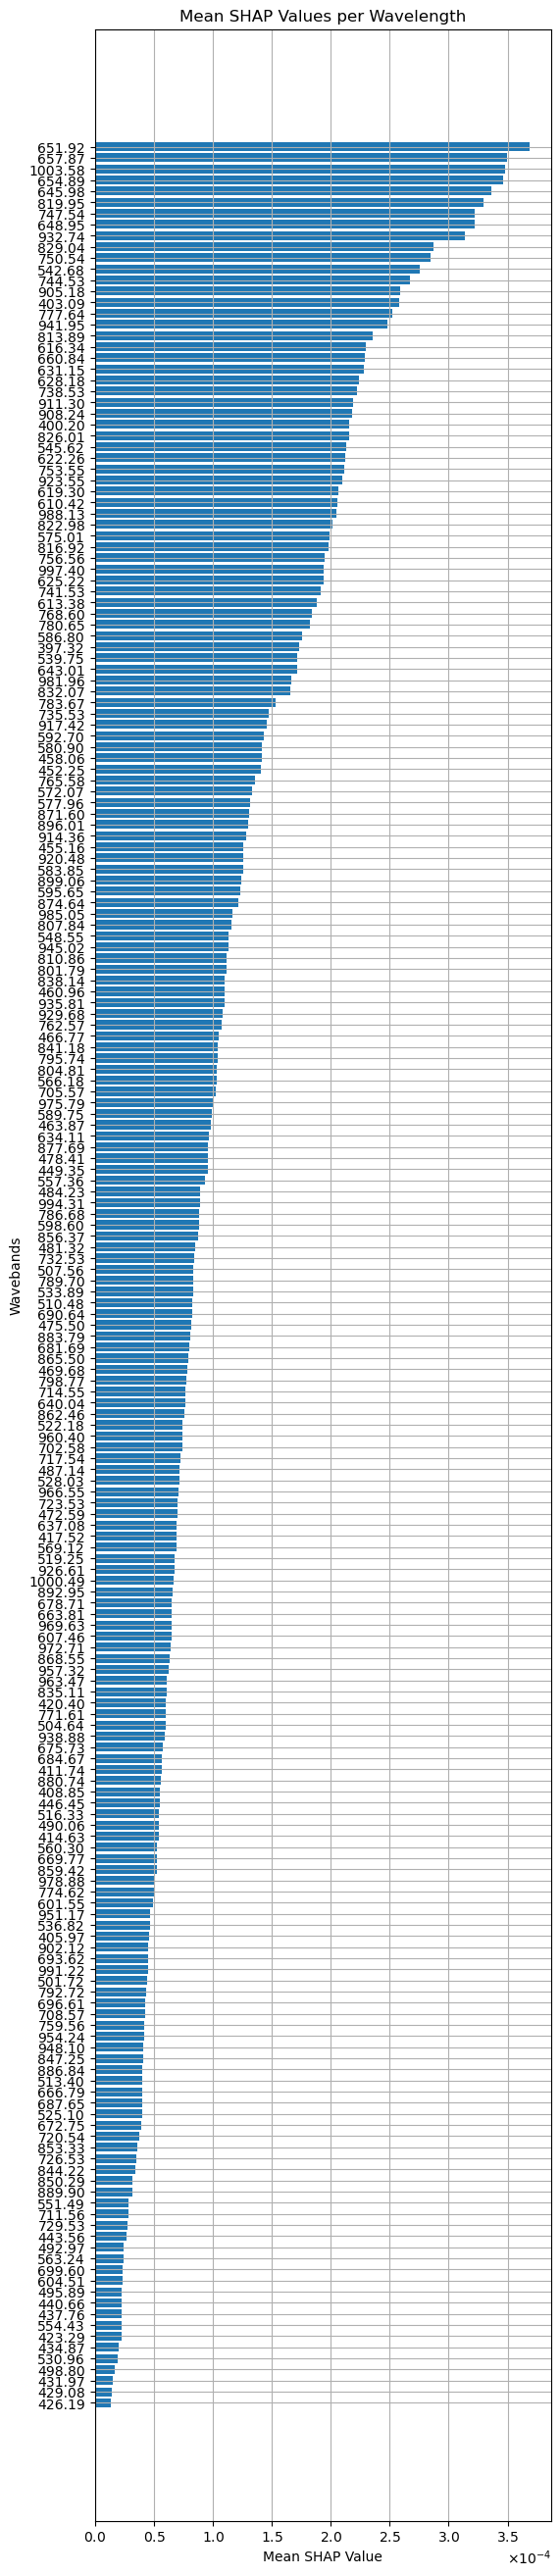

In [ ]:
# All the spectra


sorted_indices_all = np.argsort(mean_shap_per_band_flattened)[::1]
sorted_spectra_data = mean_shap_per_band_flattened[sorted_indices_all]
sorted_spectra_data_flattened = sorted_spectra_data.flatten()
sorted_wavebands = np.array(wavebands)[sorted_indices_all]


# Create a bar plot for the sorted mean SHAP values
plt.figure(figsize=(6, 33))
plt.barh(range(len(sorted_spectra_data_flattened)), sorted_spectra_data_flattened)
plt.yticks(range(len(sorted_spectra_data_flattened)), sorted_wavebands, rotation='horizontal')
plt.title("Mean SHAP Values per Wavelength")
plt.ylabel("Wavebands")
plt.xlabel("Mean SHAP Value")
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.grid(True)
plt.show()

In [57]:
import seaborn as sns
def plot_cultivar_shap(shap_values, data_type):
    cultivar_shap = shap_values[:, 0, 0, 204:]  # first pixel, any will do
    mean_cultivar_importance = np.mean(np.abs(cultivar_shap), axis=(0, 2))
    cultivars = ['Cox', 'Braeburn', 'Fuji', 'Jazz', 'Gala', 'Golden Delicious']
    sns.barplot(x=mean_cultivar_importance, y=cultivars)
    plt.title(f"Mean SHAP Importance by Cultivar Encoding - {data_type}")
    plt.show()

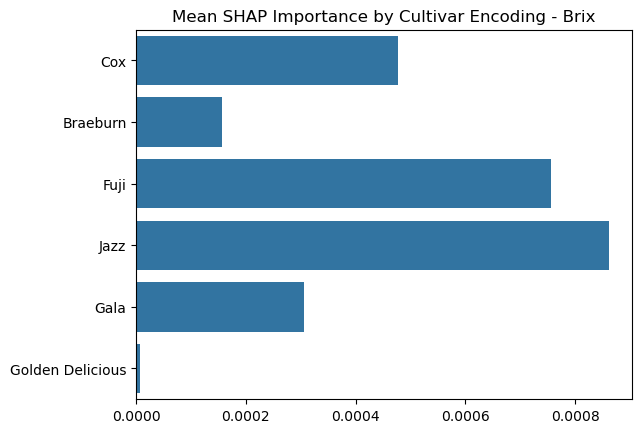

In [58]:
plot_cultivar_shap(brix_shap, "Brix")

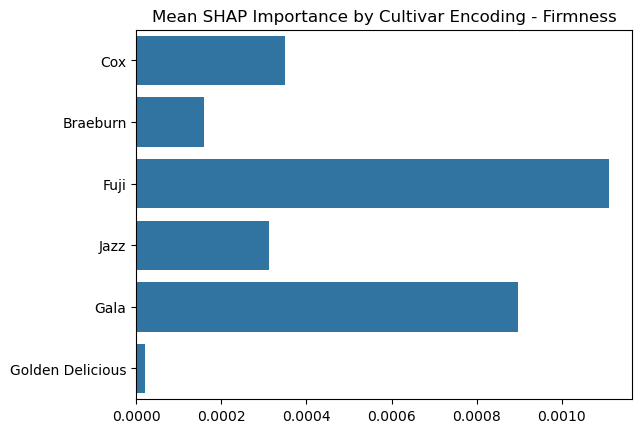

In [59]:
plot_cultivar_shap(firmness_shap, "Firmness")


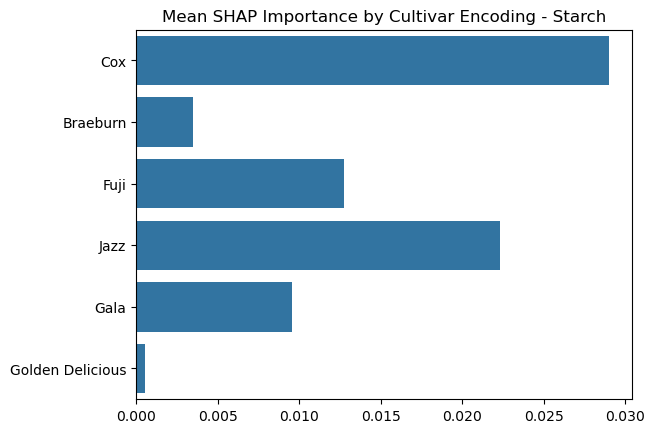

In [60]:
plot_cultivar_shap(starch_shap, "Starch")

In [34]:

def calculate_mean_shap_summary(shap_values, img_size=20):
    """
    Calculate the mean SHAP summary for the given SHAP values.

    Parameters:
    shap_values (np.array): SHAP values array with shape (num_samples, img_size, img_size, num_bands).
    img_size (int): Size of the image (default is 20).

    Returns:
    np.array: Mean SHAP summary with shape (img_size, img_size).
    """
    mean_shap_summary = np.zeros((img_size, img_size))
    sample_idx = list(range(len(shap_values)))

    for sample_num in sample_idx:
        shap_img = shap_values[sample_num, :, :, :204]
        shap_summary = np.sum(np.abs(shap_img), axis=2) # Shape: (img_size, img_size, 1)
        shap_summary_flattened = np.squeeze(shap_summary) # Shape: (img_size, img_size)
        mean_shap_summary += shap_summary_flattened

    mean_shap_summary /= len(sample_idx)
    return mean_shap_summary



def plot_heat_map(mean_shap_summary, label, data_type):
    """
    Plot a heat map of the mean SHAP summary with a label.

    Parameters:
    mean_shap_summary (np.array): Mean SHAP summary with shape (img_size, img_size).
    label (str): Label for the heat map.
    """
    plt.imshow(mean_shap_summary, cmap='hot')
    plt.text(-0.1, 1.05, label, transform=plt.gca().transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))
    plt.colorbar(label="Mean SHAP Value")
    plt.title(f"{data_type}")
    plt.axis('off')



In [37]:

mean_brix_shap_summary = calculate_mean_shap_summary(brix_shap, img_size)
mean_starch_shap_summary = calculate_mean_shap_summary(starch_shap, img_size)
mean_firmness_shap_summary = calculate_mean_shap_summary(firmness_shap, img_size)



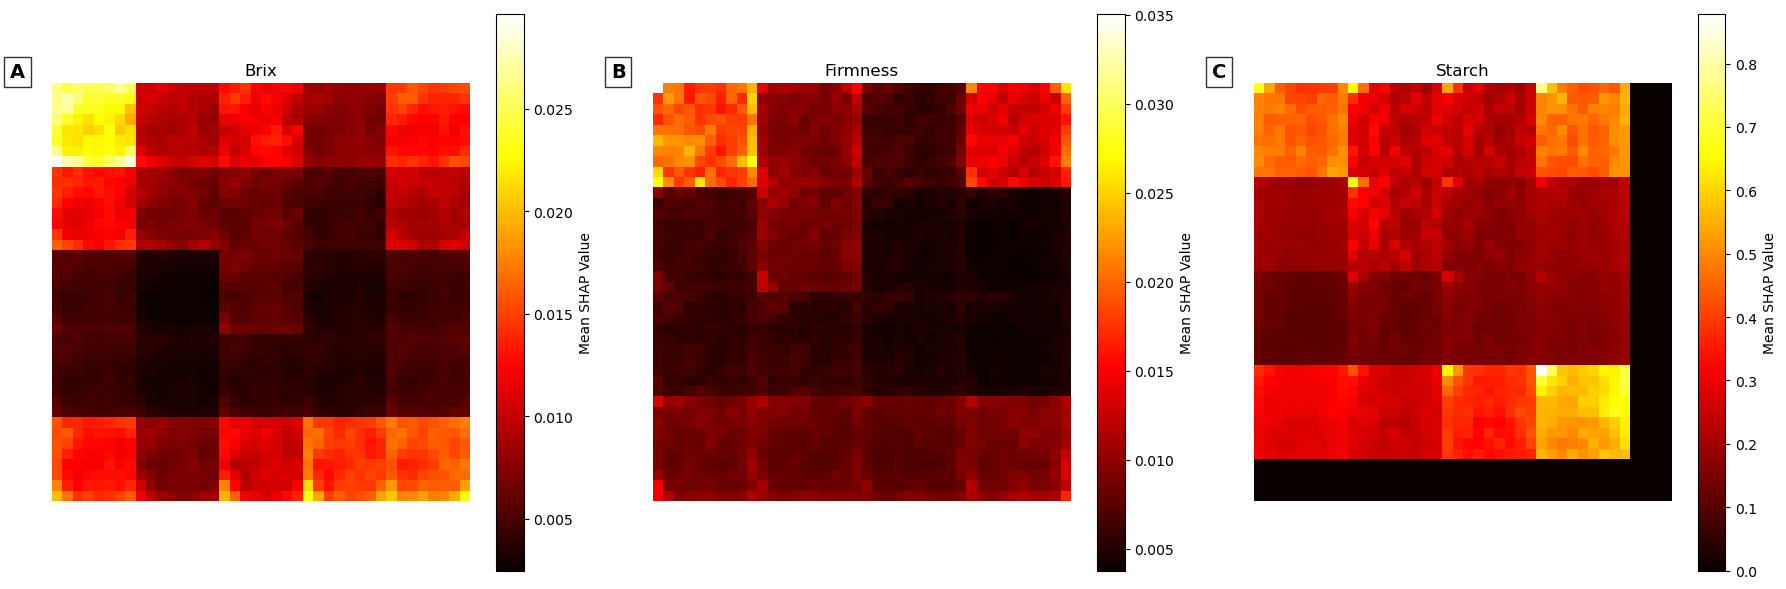

In [38]:
# Normal images 

# Plot heat maps with labels A, B, and C
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_heat_map(mean_brix_shap_summary, "A", "Brix")

plt.subplot(1, 3, 2)
plot_heat_map(mean_firmness_shap_summary, "B", "Firmness")

plt.subplot(1, 3, 3)
plot_heat_map(mean_starch_shap_summary, "C", "Starch")


plt.tight_layout()
plt.show()



### Swapping the channels in the filtered data ###

In [6]:
import numpy as np
img_size = 40
if img_size == 30 or img_size == 20:
    training_data_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'

X_train_brix          = np.load(f'{training_data_path}X_train_all_years_Brix_shuffled.npy')
Y_train_brix          = np.load(f'{training_data_path}Y_train_all_years_Brix_shuffled.npy')
X_validate_brix       = np.load(f'{training_data_path}X_validate_all_years_Brix_shuffled.npy')
Y_validate_brix       = np.load(f'{training_data_path}Y_validate_all_years_Brix_shuffled.npy')
Brix_encoder_shuffled  = np.load(f'{training_data_path}X_train_all_years_Brix_encoder_shuffled.npy')
validate_encoder        = np.load(f'{training_data_path}X_validate_all_years_Brix_encoder_shuffled.npy')


# In[40]:
X_train_brix = X_train_brix[:3]
X_validate_brix = X_validate_brix[:3]
Brix_encoder_shuffled = Brix_encoder_shuffled[:3]


spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'

X_train_brix = [spectral_path + file for file in X_train_brix]
X_validate_brix = [spectral_path + file for file in X_validate_brix]


In [7]:

def swap_quadrants(image):
    # Ensure the image has shape (H, W, C)
    h_half, w_half = 20, 20
    
    # Extract quadrants
    q1 = image[:h_half, :w_half, :]  # Top-left
    q2 = image[:h_half, w_half:, :]  # Top-right
    q3 = image[h_half:, :w_half, :]  # Bottom-left
    q4 = image[h_half:, w_half:, :]  # Bottom-right

    # Swap diagonally
    top = np.concatenate((q4, q3), axis=1)
    bottom = np.concatenate((q2, q1), axis=1)
    swapped_image = np.concatenate((top, bottom), axis=0)
    
    return swapped_image

def swap_quadrants_fast(image):
    swapped = np.empty_like(image)  # Create empty array with same shape

    # Swap diagonally (q1<->q4, q2<->q3)
    # q1 -> bottom-right
    swapped[20:, 20:, :] = image[:20, :20, :]
    # q2 -> bottom-left
    swapped[20:, :20, :] = image[:20, 20:, :]
    # q3 -> top-right
    swapped[:20, 20:, :] = image[20:, :20, :]
    # q4 -> top-left
    swapped[:20, :20, :] = image[20:, 20:, :]

    return swapped


In [8]:
from tqdm import tqdm
def data_generator_w_cultivar(file_list, targets, cultivars, batch_size, img_size, hotencoding = False):
    num_samples = len(file_list)
    missing_files = []  # List of missing files
    for offset in range(0, num_samples, batch_size):
        # Load the batch of data from file paths
        batch_files = file_list[offset: offset + batch_size]
        batch_data = []
        batch_targets = []
        batch_cultivars = []
        
        # File loading and handling - ensures model runs if file not found
        for i, file in enumerate(tqdm(batch_files, desc=f"Processing batch starting at index {offset}")):
            try:
                data = np.load(file)
                print(f"Processing file {file} with index {i + offset}")
                
                if img_size == 40 or img_size ==20:
                    data_reduced = data[5:-5, 5:-5, :] # Remove 5 pixels from each edge
                    data_reduced = swap_quadrants_fast(data_reduced)
                    batch_data.append(data_reduced)
                else:
                    swapped_data = swap_quadrants_fast(data)
                    batch_data.append(swapped_data)
                                    
                batch_targets.append(targets[offset + i])
                batch_cultivars.append(cultivars[offset + i])

                                
            except FileNotFoundError:
                missing_files.append(file)
                print(f"File not found: {file}. Skipping...")
                continue

        # Convert lists to numpy arrays
        batch_data = np.array(batch_data)  # Shape: (batch_size, 20, 20, 204)
        batch_targets = np.array(batch_targets)  # Shape: (batch_size,)
        batch_cultivars = np.array(batch_cultivars)  # Shape: (batch_size, 6)
        
        if len(batch_data) == 0:
            continue # Skip if no data loaded

                   
        # Expand cultivar information to match the input data's spatial dimensions
        expanded_cultivars = np.repeat(batch_cultivars[:, np.newaxis, np.newaxis, :], img_size, axis=1) # Adds singleton dimensions to match the input data's spatial dimensions (batchsize, 1, 1, 1, 6)
        expanded_cultivars = np.repeat(expanded_cultivars, img_size, axis=2)

        # Concatenate cultivar information with the original data along the last axis
        combined_data = np.concatenate([batch_data, expanded_cultivars], axis=-1)  # Shape: (batch_size, 20, 20, 210)

        # Yield the combined data and targets
        yield combined_data, batch_targets

        # After the loop, print and save the missing files
        if missing_files:
            print(f"Missing files: {missing_files}")
            missing_files = []  # Clear the list after saving
        


In [9]:

def fast_data_generator(file_list, targets, cultivars, batch_size, img_size, band_filter=None):
    num_samples = len(file_list)
    missing_files = []

    def preprocess(file, i, offset):
        try:
            data = np.load(file)

            # Crop and swap quadrants
            if img_size == 40 or img_size == 20:
                data = data[5:-5, 5:-5, :]
            data = swap_quadrants_fast(data)

            # Filter spectral bands if required
            if band_filter is not None:
                data = data[:, :, band_filter]

            # Expand cultivar info to match spatial dims
            cultivar = cultivars[offset + i]
            cultivar_exp = np.broadcast_to(cultivar.reshape(1, 1, -1), (img_size, img_size, cultivar.shape[-1]))

            # Concatenate along the channel axis
            combined = np.concatenate([data, cultivar_exp], axis=-1)

            return combined, targets[offset + i]

        except FileNotFoundError:
            missing_files.append(file)
            print(f"File not found: {file}. Skipping...")
            return None, None

    while True:
        # tqdm wraps the outer loop to show progress per epoch
        for offset in tqdm(range(0, num_samples, batch_size), desc="Epoch file processing"):
            batch_files = file_list[offset:offset + batch_size]

            # Process each file in the batch
            processed = [preprocess(f, i, offset) for i, f in enumerate(batch_files)]

            # Filter out any None results due to missing files
            processed = [p for p in processed if p[0] is not None]

            if not processed:
                continue

            batch_data, batch_targets = zip(*processed)
            return np.stack(batch_data), np.array(batch_targets)


In [41]:
import time
start = time.time()
gen= data_generator_w_cultivar(X_train_brix, Y_train_brix[:3], Brix_encoder_shuffled, batch_size=2, img_size=img_size)
end = time.time()
print(f"Data generation took {end - start} seconds")

Data generation took 0.00011968612670898438 seconds


In [ ]:
# Data generation took 0.006512880325317383 seconds - fast funciton
# Data generation took 0.00816798210144043 seconds
# Data generation took 0.01615595817565918 seconds


In [42]:
print(data.shape) # fast
print(y.shape)

NameError: name 'data' is not defined

In [43]:
x,y = next(gen)

Processing batch starting at index 0: 100%|██████████| 2/2 [00:00<00:00, 483.30it/s]

Processing file /media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Braeburn_1453_7768.npy with index 0
Processing file /media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Fuji_1423_11860.npy with index 1


In [82]:
print(x.shape)

(2, 40, 40, 210)


(40, 40, 210)


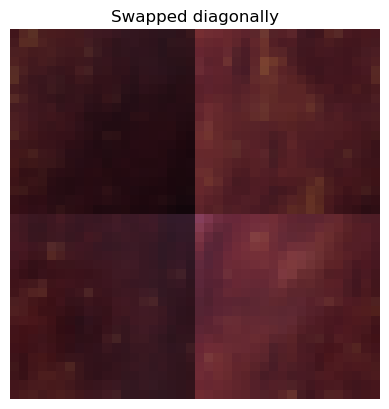

In [44]:
import matplotlib.pyplot as plt

original_RGB_img = x[1]
print(original_RGB_img.shape)
red_band = original_RGB_img[:, :, 69]
green_band = original_RGB_img[:, :, 52]
blue_band = original_RGB_img[:, :, 18]
rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
# # Display image
plt.imshow(rgb_image)
plt.axis("off")
plt.title("Swapped diagonally")
plt.show()


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
# Load data
output_dir = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/Shap_values/May2025/swapped_images/' # Use swapped shapped values

brix_shap_swapped_img = pd.read_pickle(f'{output_dir}shap_values_brix_swapped_images.pkl')
firmness_shap_swapped_img = pd.read_pickle(f'{output_dir}shap_values_firmness_swapped_images.pkl')
starch_shap_swapped_img = pd.read_pickle(f'{output_dir}shap_values_starch_swapped_images.pkl')

In [27]:

def calculate_mean_shap_summary(shap_values, img_size=20):
    """
    Calculate the mean SHAP summary for the given SHAP values.

    Parameters:
    shap_values (np.array): SHAP values array with shape (num_samples, img_size, img_size, num_bands).
    img_size (int): Size of the image (default is 20).

    Returns:
    np.array: Mean SHAP summary with shape (img_size, img_size).
    """
    mean_shap_summary = np.zeros((img_size, img_size))
    sample_idx = list(range(len(shap_values)))

    for sample_num in sample_idx:
        shap_img = shap_values[sample_num, :, :, :204]
        shap_summary = np.sum(np.abs(shap_img), axis=2) # Shape: (img_size, img_size, 1)
        shap_summary_flattened = np.squeeze(shap_summary) # Shape: (img_size, img_size)
        mean_shap_summary += shap_summary_flattened

    mean_shap_summary /= len(sample_idx)
    return mean_shap_summary



def plot_heat_map(mean_shap_summary, label, data_type):
    """
    Plot a heat map of the mean SHAP summary with a label.

    Parameters:
    mean_shap_summary (np.array): Mean SHAP summary with shape (img_size, img_size).
    label (str): Label for the heat map.
    """
    plt.imshow(mean_shap_summary, cmap='hot')
    plt.text(-0.1, 1.05, label, transform=plt.gca().transAxes, fontsize=14, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8))
    plt.colorbar(label="Mean SHAP Value")
    plt.title(f"{data_type}")
    plt.axis('off')


In [35]:
mean_brix_shap_summary_swapped_img = calculate_mean_shap_summary(brix_shap_swapped_img, img_size)
mean_starch_shap_summary_swapped_img = calculate_mean_shap_summary(starch_shap_swapped_img, img_size)
mean_firmness_shap_summary_swapped_img = calculate_mean_shap_summary(firmness_shap_swapped_img, img_size)

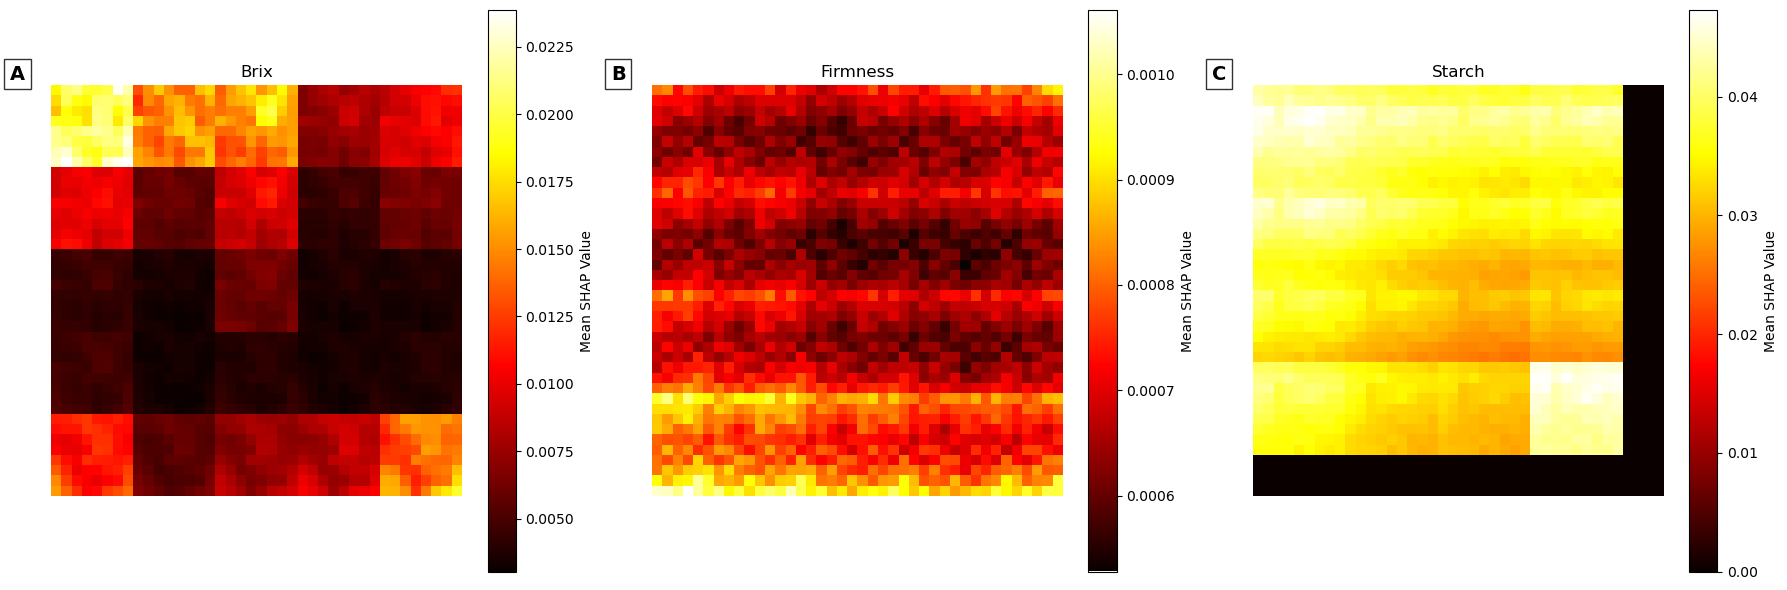

In [36]:

# With swapped images, plot heat maps with labels A, B, and C 
# Plot heat maps with labels A, B, and C
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_heat_map(mean_brix_shap_summary, "A", "Brix")

plt.subplot(1, 3, 2)
plot_heat_map(mean_firmness_shap_summary, "B", "Firmness")

plt.subplot(1, 3, 3)
plot_heat_map(mean_starch_shap_summary, "C", "Starch")


plt.tight_layout()
plt.show()